In [24]:
from langgraph.graph import StateGraph ,START ,END
from typing import TypedDict , Annotated , Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_groq import ChatGroq
import operator
from langchain_core.messages import SystemMessage , HumanMessage

In [25]:
load_dotenv()

True

In [26]:
generator_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7
)
evaluator_llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)
optimizer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

In [27]:
from pydantic import BaseModel , Field

class TweetEvaluation(BaseModel):
    evaluation : Literal["approved" , "needs_improvement"] = Field(... ,description="Final Evaluation result.")
    feedback : str = Field(... , description="Constructive feedback for the tweet.")
    # score : int = Field(... , ge=0 , le=5 , description="total score from rubric (0  to 5).")

In [28]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [29]:
# state
class TweetState(TypedDict):

    topic : str 
    tweet : str 
    evaluation : Literal['approved' , 'needs_improvemnt']
    feedback : str 
    iteration : int 
    max_iteration : int 

    tweet_history : Annotated[list[str] , operator.add]
    feedback_history : Annotated[list[str] , operator.add]

In [30]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever twitter/X influencer"),
        HumanMessage(content=f"""
write a short , original and hillarious tweet on the topic : "{state['topic']}". 

Rules :
- Do NOT use question - Answer format
- MAX 300 Characters
- Use obeservational humor , irony , sarcasm or cultural reference 
- think in meme logic , punchualities or relatable takes
- use simple , day to day english
""")
# - this is version {state['iteration'] + 1}
    ]

    # send to generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet' : response , 'tweet_history' : [response]}


In [31]:
def evaluate_tweet(state : TweetState):

    # prompt
    messages = [
    SystemMessage(
        content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
    ),
    HumanMessage(
        content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 300 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
"""
    )
] 

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation' : response.evaluation , 'feedback':response.feedback ,'feedback_history' : [response.feedback]}

In [32]:
def optimize_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(
        content="You punch up tweets for virality and humor based on given feedback."
    ),
    HumanMessage(
        content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 300 characters.
"""
    )
]
    
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet' : response , 'iteration' : iteration , 'tweet_history' : [response]}

In [33]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    
    else:
        return 'needs_improvment'

In [34]:
graph = StateGraph(TweetState)

# Nodes 
graph.add_node('generate' , generate_tweet)
graph.add_node('evaluate' , evaluate_tweet)
graph.add_node('optimize' , optimize_tweet)

# edges
graph.add_edge(START , 'generate')
graph.add_edge('generate' , 'evaluate')

graph.add_conditional_edges('evaluate' , route_evaluation ,{'approved' : END , 'needs_improvment' : 'optimize'} )

graph.add_edge('optimize' , 'evaluate')

workflow = graph.compile()

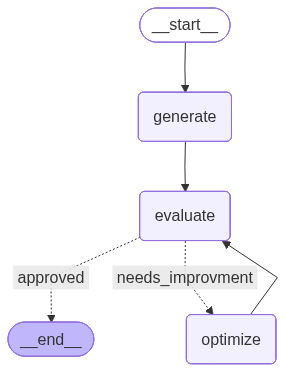

In [35]:
workflow

In [39]:
initial_state = {
    "topic" : "edhgf",
    "iteration" : 1,
    "max_iteration" : 5
}
workflow.invoke(initial_state)

{'topic': 'edhgf',
 'tweet': '"just spent 10 mins typing \'edhgf\' into google and I\'m pretty sure I\'ve single-handedly kept autocorrect in business" #edhgf',
 'evaluation': 'approved',
 'feedback': 'The tweet is original and clever, leveraging a relatable tech frustration (autocorrect overcorrection) with a humorous twist. Its brevity and hashtag (#edhgf) enhance shareability, and the format avoids clichéd joke structures. While the humor is situational, it effectively targets a modern, tech-savvy audience. Strengths include punchiness and virality potential; the only minor drawback is that the joke’s niche appeal might limit broader resonance.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"just spent 10 mins typing \'edhgf\' into google and I\'m pretty sure I\'ve single-handedly kept autocorrect in business" #edhgf'],
 'feedback_history': ['The tweet is original and clever, leveraging a relatable tech frustration (autocorrect overcorrection) with a humorous twist. Its